# PROYECTO FINAL APRENDIZAJE SUPERVISADO 2



# Datos del alumno

**Nombre**: Adrián


**Apellidos**: Robles Arques


**Grupo:** A1

FASE 3
---------------------------------

Recordamos que el objetivo de este proyecto es predecir si un trabajador va a abandonar la empresa o no (variable `left`).

Objetivos del sprint:

*   Aplicar al menos dos tipos diferentes de métodos de ensembles (uno de Bagging y otro de Boosting). Y probar dos configuraciones diferentes de hiperparámetros para cada uno.

*   Comparar y discutir los resultados, identificando el mejor ensemble en cuanto a poder predictivo.

*   Obtención de la importancia de las variables para el mejor método.

Para este caso continuaremos con los datos empleados en secciones anteriores.

Lo primero de todo será importar las librerías necesarias.

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix,
                             classification_report)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     learning_curve,
                                     validation_curve,
                                     train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample
from warnings import filterwarnings

%matplotlib inline

Y las específicas para este sprint.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

Cargamos las matrices de train y test que hemos calculado en el sprint 1.

In [ ]:
##Descarga manual: https://drive.google.com/file/d/1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9/view?usp=sharing
##Descarga manual: https://drive.google.com/file/d/1O1BRGwSd81TOOpaQvoo5BHDsrPEruz93/view?usp=sharing
##Descarga manual: https://drive.google.com/file/d/1u3yI5L_2YI77uF_WT9ysIzw8dydVlQSh/view?usp=sharing
##Descarga manual: https://drive.google.com/file/d/1eWo_m2gbihSuUQeOhH8I8Q0uudluQKBT/view?usp=sharing


#Descargamos los ficheros de Google Drive (si lo ejecutais en un entorno diferente a Google Colab, tenéis que intalar previamente wget en vuestro PC)
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9' -O 'y_train.npy'
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1O1BRGwSd81TOOpaQvoo5BHDsrPEruz93' -O 'y_test.npy'
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1u3yI5L_2YI77uF_WT9ysIzw8dydVlQSh' -O 'X_train.npy'
#!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1eWo_m2gbihSuUQeOhH8I8Q0uudluQKBT' -O 'X_test.npy'

--2023-07-06 11:58:08--  https://drive.google.com/uc?export=download&id=1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9
Resolving drive.google.com (drive.google.com)... 64.233.189.139, 64.233.189.100, 64.233.189.102, ...
Connecting to drive.google.com (drive.google.com)|64.233.189.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-04-b0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/gf8htoipi4h7ke5s5t40ck0esim89848/1688644650000/14644984037434537262/*/1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9?e=download&uuid=0fab2e4d-70fe-4327-95fe-e9c5c33a74cb [following]
--2023-07-06 11:58:09--  https://doc-04-b0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/gf8htoipi4h7ke5s5t40ck0esim89848/1688644650000/14644984037434537262/*/1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9?e=download&uuid=0fab2e4d-70fe-4327-95fe-e9c5c33a74cb
Resolving doc-04-b0-docs.googleusercontent.com (doc-04-b0-docs.googleusercontent.com)... 64.233.187.132, 2404:

In [ ]:
#Definimos función para crear la curva ROC
def plot_roc_curve(y_test, y_train, y_pred_test, y_pred_train, p = 2):
  fpr_test, tpr_test, thresholds = roc_curve(y_test, y_pred_test)
  roc_auc_test = roc_auc_score(y_test, y_pred_test)

  fpr_train, tpr_train, thresholds = roc_curve(y_train, y_pred_train)
  roc_auc_train = roc_auc_score(y_train, y_pred_train)

  plt.figure()
  plt.plot(fpr_test, tpr_test, color='darkorange', lw=1, label='Curva ROC test (AUC = {})'.format(round(roc_auc_test,p)))
  plt.plot(fpr_train, tpr_train, color='navy', lw=1, label='Curva ROC train (AUC = {})'.format(round(roc_auc_train,p)))
  plt.legend(loc="lower right")
  plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('Tasa de falso positivo')
  plt.ylabel('Tasa de auténtico positivo')
  plt.title('Curva ROC')

  return roc_auc_test, roc_auc_train

In [ ]:
from google.colab import files

In [ ]:
#Cargamos desde local los datos previos
uploaded = {}
uploaded = files.upload()
X_train = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
X_test = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
y_train = np.load(list(uploaded.keys())[0])

uploaded = {}
uploaded = files.upload()
y_test = np.load(list(uploaded.keys())[0])

Saving X_train.npy to X_train.npy


Saving X_test.npy to X_test.npy


Saving y_train.npy to y_train.npy


Saving y_test.npy to y_test.npy


Verificamos que las dimensiones se corresponden con la partición de 80% de los datos para el conjunto de train y 20% de los datos para test.

In [ ]:
X_train, X_test,y_train,y_test = np.load("X_train.npy"),np.load("X_test.npy"),np.load("y_train.npy"),np.load("y_test.npy")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(11999, 18)
(3000, 18)
(11999,)
(3000,)


In [ ]:
#Cargar datos de las columnas desde PC
uploaded = {}
uploaded = files.upload()
columnas = uploaded[list(uploaded.keys())[0]]

Saving nom_columnas.txt to nom_columnas.txt


In [ ]:
#Generando la lista de nombres de columnas
nom_columnas = columnas.decode('utf-8').split('\n')
nom_columnas = nom_columnas[:-1] #Aparece un espacio al final
left_ind = nom_columnas.index('left')

#Eliminamos left, dado que es la variable objetivo
nom_columnas = nom_columnas[:left_ind] + nom_columnas[left_ind+1:]
nom_columnas

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'salary',
 'dep_IT',
 'dep_RandD',
 'dep_accounting',
 'dep_hr',
 'dep_management',
 'dep_marketing',
 'dep_product_mng',
 'dep_sales',
 'dep_support',
 'dep_technical']

# CUESTION 1 - Modelo de tipo Bagging

## Combinación de hiperparámetros 1

In [ ]:
# Instanciamos el modelo con los hiperparámetros más adecuados
rf1 = RandomForestClassifier(
    n_estimators= 200,
    criterion= 'gini',
    max_depth= 5,
    min_samples_split= 4,
    max_features= 'sqrt',
    random_state= 42,
    class_weight= 'balanced')

In [ ]:
# Entrenamos el modelo con los datos de entrenamiento
rf1.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=4, n_estimators=200, random_state=42)

In [ ]:
# Obtenemos las predicciones para el conjunto de test
Y_pred = rf1.predict(X_test)
Y_pred_p = rf1.predict_proba(X_test)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train = rf1.predict(X_train)
Y_pred_train_p = rf1.predict_proba(X_train)[:,1]

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

<Figure size 1000x1000 with 0 Axes>

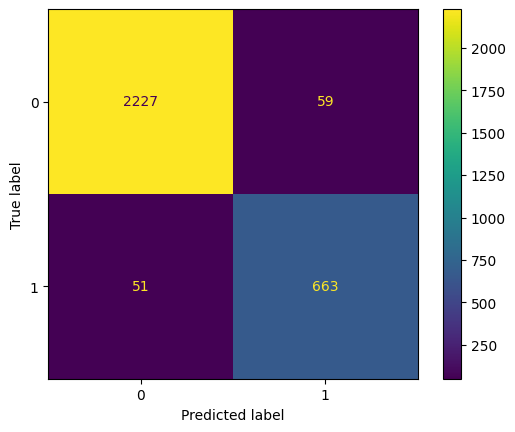

              precision    recall  f1-score   support

           0      0.978     0.974     0.976      2286
           1      0.918     0.929     0.923       714

    accuracy                          0.963      3000
   macro avg      0.948     0.951     0.950      3000
weighted avg      0.963     0.963     0.963      3000



In [ ]:
# Evaluar la capacidad predictiva del modelo
cm_rf1 = confusion_matrix(y_test, Y_pred)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_rf1)
ax.plot()
plt.show()

report1 = classification_report(y_test, Y_pred, digits = 3)
print(report1)

(0.9793040575810377, 0.9842129549050194)

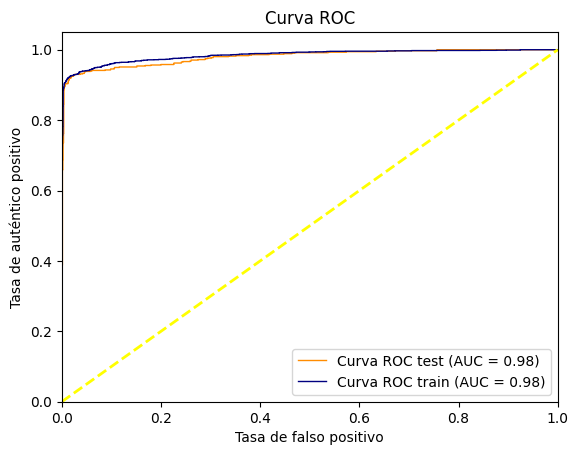

In [ ]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test1, AUC_train1 = plot_roc_curve(y_test, y_train, Y_pred_p, Y_pred_train_p, p = 4)

In [ ]:
# Obtenemos la relevancia de los parámetros
imp_params1 = pd.Series(rf1.feature_importances_, index=nom_columnas, name= 'Features importances').sort_values(ascending=False)
imp_params1

,Features importances
satisfaction_level,0.318597
time_spend_company,0.239359
number_project,0.178120
average_montly_hours,0.123583
last_evaluation,0.108906
Work_accident,0.014912
salary,0.011329
promotion_last_5years,0.001953
dep_RandD,0.000713
dep_technical,0.000615


## Combinación de hiperparámetros 2

In [ ]:
# Instanciamos el modelo con los hiperparámetros más adecuados
rf2 = RandomForestClassifier(
    n_estimators= 2000,
    criterion= 'entropy',
    max_depth= 5,
    min_samples_split= 10,
    max_features= 'log2',
    random_state= 42,
    class_weight= 'balanced')

In [ ]:
# Entrenamos el modelo con los datos de entrenamiento
rf2.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, max_features='log2', min_samples_split=10,
                       n_estimators=2000, random_state=42)

In [ ]:
# Obtenemos las predicciones para el conjunto de test
Y_pred2 = rf2.predict(X_test)
Y_pred_p2 = rf2.predict_proba(X_test)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train2 = rf2.predict(X_train)
Y_pred_train_p2 = rf2.predict_proba(X_train)[:,1]

<Figure size 1000x1000 with 0 Axes>

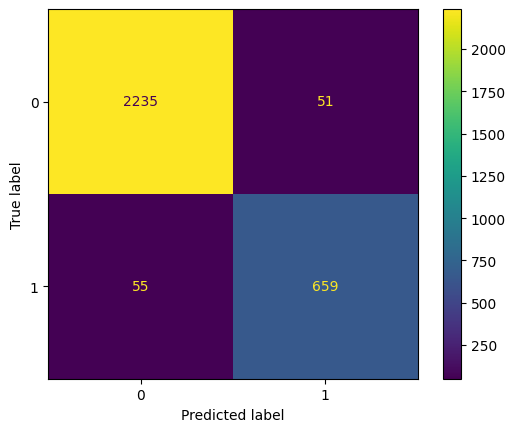

              precision    recall  f1-score   support

           0      0.976     0.978     0.977      2286
           1      0.928     0.923     0.926       714

    accuracy                          0.965      3000
   macro avg      0.952     0.950     0.951      3000
weighted avg      0.965     0.965     0.965      3000



In [ ]:
# Evaluar la capacidad predictiva del modelo
cm_rf2 = confusion_matrix(y_test, Y_pred2)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_rf2)
ax.plot()
plt.show()

report2 = classification_report(y_test, Y_pred2, digits = 3)
print(report2)

(0.9791735591874545, 0.9842455752190368)

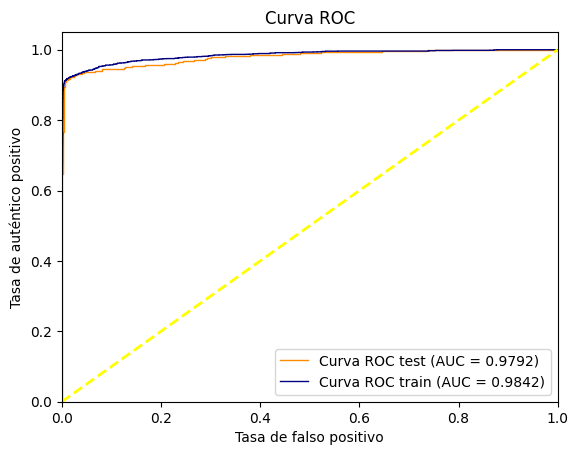

In [ ]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test2, AUC_train2 = plot_roc_curve(y_test, y_train, Y_pred_p2, Y_pred_train_p2, p=4)

In [ ]:
# Comparamos la relevancia de los parámetros
imp_params2 = pd.Series(rf1.feature_importances_, index=nom_columnas, name= 'Features importances').sort_values(ascending=False)
imp_params2

,Features importances
satisfaction_level,0.318597
time_spend_company,0.239359
number_project,0.178120
average_montly_hours,0.123583
last_evaluation,0.108906
Work_accident,0.014912
salary,0.011329
promotion_last_5years,0.001953
dep_RandD,0.000713
dep_technical,0.000615


# CUESTION 2 - Modelo de tipo Boosting

## Combinación de hiperparámetros 1

In [ ]:
# Instanciamos el modelo con los hiperparámetros más adecuados
ABC = AdaBoostClassifier(
    estimator = None, #Esto define el clasificador como un árbol de decisión de profundidad 1
    n_estimators= 200,
    learning_rate= 0.1,
    random_state= 42)

In [ ]:
# Entrenamos el modelo con los datos de entrenamiento
ABC.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=42)

In [ ]:
# Obtenemos las predicciones para el conjunto de test
Y_pred3 = ABC.predict(X_test)
Y_pred_p3 = ABC.predict_proba(X_test)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train3 = ABC.predict(X_train)
Y_pred_train_p3 = ABC.predict_proba(X_train)[:,1]

<Figure size 1000x1000 with 0 Axes>

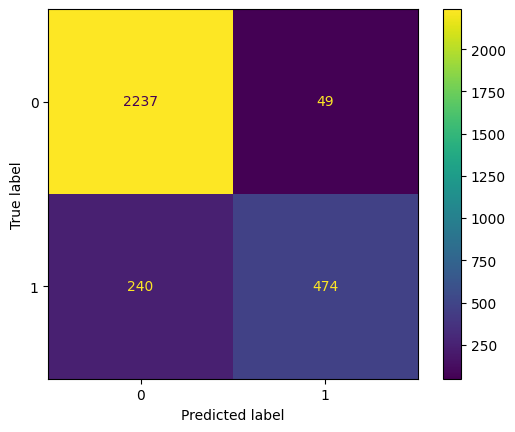

              precision    recall  f1-score   support

           0      0.903     0.979     0.939      2286
           1      0.906     0.664     0.766       714

    accuracy                          0.904      3000
   macro avg      0.905     0.821     0.853      3000
weighted avg      0.904     0.904     0.898      3000



In [ ]:
# Evaluar la capacidad predictiva del modelo
cm_ABC = confusion_matrix(y_test, Y_pred3)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_ABC)
ax.plot()
plt.show()

report3 = classification_report(y_test, Y_pred3, digits = 3)
print(report3)

In [ ]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test3, AUC_train3 = plot_roc_curve(y_test, y_train, Y_pred_p3, Y_pred_train_p3, p=4)

NameError: name 'plot_roc_curve' is not defined

In [ ]:
#Obtenemos la relevancia de los parámetros para este modelo
imp_params3 = pd.Series(ABC.feature_importances_, index=nom_columnas, name= 'Features importances').sort_values(ascending=False)
imp_params3

,Features importances
satisfaction_level,0.532726
time_spend_company,0.245859
number_project,0.168377
last_evaluation,0.032949
Work_accident,0.012354
average_montly_hours,0.007734
dep_management,0.000000
dep_support,0.000000
dep_sales,0.000000
dep_product_mng,0.000000


## Combinación de hiperparámetros 2

Vamos a emplear como cuarto modelo el Gradient Boos Classifier, aunque el modelo recomendado para sets de datos con n> 10000 es Histogram Gradient Boost Classifier. Este método funciona más rápido que el GradientBoostClassifier habitual para sets grandes, y los parámetros de ajuste son muy similares, sin embargo no permite obtener los parámetros por importancia.

In [ ]:
#Instanciamos el modelo GradientBoosClasifier
GBC = GradientBoostingClassifier(
    loss= 'log_loss',
    learning_rate= 0.1,
    max_leaf_nodes= None,
    max_depth= 5,
    min_samples_leaf= 25,
    max_features= 'sqrt',
    subsample= 0.8,
    random_state= 42)

In [ ]:
# Entrenamos el modelo con los datos de entrenamiento
GBC.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, max_features='sqrt',
                           min_samples_leaf=25, random_state=42, subsample=0.8)

In [ ]:
# Obtenemos las predicciones para el conjunto de test
Y_pred4 = GBC.predict(X_test)
Y_pred_p4 = GBC.predict_proba(X_test)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train4 = GBC.predict(X_train)
Y_pred_train_p4 = GBC.predict_proba(X_train)[:,1]

<Figure size 1000x1000 with 0 Axes>

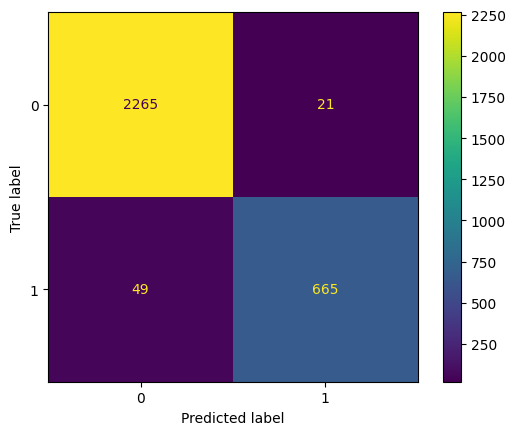

              precision    recall  f1-score   support

           0      0.979     0.991     0.985      2286
           1      0.969     0.931     0.950       714

    accuracy                          0.977      3000
   macro avg      0.974     0.961     0.967      3000
weighted avg      0.977     0.977     0.977      3000



In [ ]:
# Evaluar la capacidad predictiva del modelo
cm_GBC = confusion_matrix(y_test, Y_pred4)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_GBC)
ax.plot()
plt.show()

report4 = classification_report(y_test, Y_pred4, digits = 3)
print(report4)

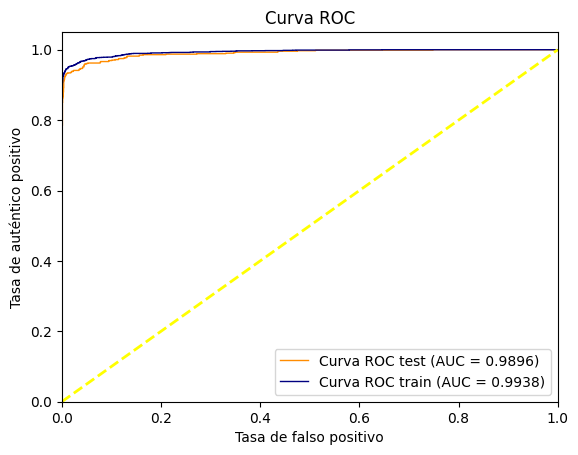

In [ ]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test4, AUC_train4 = plot_roc_curve(y_test, y_train, Y_pred_p4, Y_pred_train_p4, p=4)

In [ ]:
# Obtenemos la relevancia de los parámetros según este modelo
imp_params4 = pd.Series(GBC.feature_importances_, index=nom_columnas, name= 'Features importances').sort_values(ascending=False)
imp_params4

,Features importances
satisfaction_level,0.350541
number_project,0.182755
time_spend_company,0.176586
average_montly_hours,0.137738
last_evaluation,0.127567
Work_accident,0.012116
salary,0.007985
dep_management,0.001027
dep_technical,0.000968
dep_RandD,0.000723


# CUESTION 3 - ¿Qué modelo tiene mayor poder predictivo?

Comparar los diferentes árboles entrenados empleando las métricas más adecuadas para un problema desblanaceado como el nuestro.

In [ ]:
#Vamos a guardar los informes en DataFrames para comparar mejor
eval1 = pd.DataFrame(classification_report(y_test, Y_pred, output_dict=True)).transpose()
eval2 = pd.DataFrame(classification_report(y_test, Y_pred2, output_dict=True)).transpose()
eval3 = pd.DataFrame(classification_report(y_test, Y_pred3, output_dict=True)).transpose()
eval4 = pd.DataFrame(classification_report(y_test, Y_pred4, output_dict=True)).transpose()

In [ ]:
for i in [eval1, eval2, eval3, eval4]:
    print('------------------------------------------')
    print('f1-score 1 = ', round(i['f1-score']['1'],5))
    print('f1-score 0 = ', round(i['f1-score']['0'],5))

------------------------------------------
f1-score 1 =  0.9234
f1-score 0 =  0.9759
------------------------------------------
f1-score 1 =  0.92556
f1-score 0 =  0.97684
------------------------------------------
f1-score 1 =  0.76637
f1-score 0 =  0.93932
------------------------------------------
f1-score 1 =  0.95
f1-score 0 =  0.98478


En este caso, los resultados de los 4 modelos entrenados son muy similares y tienen un gran poder de precisión, excepto para el caso del AdaBoost, que hierra de forma específica en la tasa de falsos negativos, aunque su tasa de falsos positivos sea inferior a las de los métodos de Random Forest.

Como medidas de evaluación y comparación de los modelos vamos a usar en este caso el f-1 Score para los resultados de 0, y 1 (Quedarse y Marcharse, respectivamente), así como la matriz de confusión y la curva ROC y el área bajo la curva. Emplearemos la métrica f-1 dado que, por su construcción matemática, carga con información tanto de la precision como del recall, dado que se calcula a partir de ambas.

Dado que se trata de un problema desbalanceado, donde la proporción de uno de los dos casos para la clasificación binaria es mucho más abundante que el otro, en este caso 0 vs. 1, métricas como la exactitud (accuracy) no son fiables.

Atendiendo a estas métricas, el peor de los modelos estrenados sería el AdaBoost, con notable diferencia tanto en el AUC como en el valor de f-1 para la respuesta '1' o 'Marcharse', donde vemos que comete un mayor número de catalogaciones como falso negativo que los otros 3 modelos (Visible en la matriz de confusión), teniendo como opciones intermedias bastante próximas al mejor modelo ambos Random Forest, obteniendo los mejores resultados en las métricas el Gradient Boost Classifier.

Este modelo permite el uso de muchos más hiperparámetros que el AdaBoost, siendo el GradientBoost una generalización de este. Esto nos permite un ajuste más fino en este caso. Además, el uso de un modelo no estocástico, al definir `subsample= 0.8` introduce el método de bootstraping en el algoritmo. Por tanto, no estamos entrenando con una muestra más pequeña, si no con muestras que añaden reemplazo de ciertas muestras (en concreto, un 20%) por otros valores repetidos de los ya contemplados.

A la luz de los resultados analizados, este es el mejor resultado de los cuatro modelos. Otro algoritmo que podríamos emplear en este caso para tratar de mejorar el resultado es el HistGradientBoostClasifier, que realiza el algoritmo de Gradient Boost mediante histogramas y permite añadir el método de binning. Sin embargo, si se ha optado por no emplear este modelo es porque no está implementado la estracción posterior de la relevancia de los parámetros analizados para clasificar las variables explicativas, de modo que no podría responderse la siguiente cuestión.

# CUESTION 4 - Importancia de las variables para el modelo

Evaluar las variables más importantes para el mejor modelo elegido. ¿Tiene sentido usar estas variables para evaluar si un empleado va a abandonar la empresa?

In [ ]:
#Creamos un dataframe uniendo los parámetros y sus relevancias calculadas
param_imp_total = pd.concat([imp_params1, imp_params2, imp_params3, imp_params4], axis=1)
param_imp_total.columns = ['RF1', 'RF2', 'ABC', 'GBC']
param_imp_total

,RF1,RF2,ABC,GBC
satisfaction_level,0.318597,0.318597,0.532726,0.350541
time_spend_company,0.239359,0.239359,0.245859,0.176586
number_project,0.178120,0.178120,0.168377,0.182755
average_montly_hours,0.123583,0.123583,0.007734,0.137738
last_evaluation,0.108906,0.108906,0.032949,0.127567
Work_accident,0.014912,0.014912,0.012354,0.012116
salary,0.011329,0.011329,0.000000,0.007985
promotion_last_5years,0.001953,0.001953,0.000000,0.000461
dep_RandD,0.000713,0.000713,0.000000,0.000723
dep_technical,0.000615,0.000615,0.000000,0.000968


In [ ]:
#Calculamos la relevancia total de los primeros cinco parámetros
val5GBC = sum(param_imp_total['GBC'][:5])
val5ABC = sum(param_imp_total['ABC'][:5])
val5RF2 = sum(param_imp_total['RF2'][:5])
val5RF1 = sum(param_imp_total['RF1'][:5])
val5Serie = pd.Series([val5GBC, val5ABC, val5RF2, val5RF1], index=['GBC', 'ABC', 'RF2', 'RF1'])
val5Serie

,0
GBC,0.975186
ABC,0.987646
RF2,0.968565
RF1,0.968565


In [ ]:
#Comprobemos ahora la relevancia de los cuatro primeros
val4GBC = sum(param_imp_total['GBC'][:4])
val4ABC = sum(param_imp_total['ABC'][:4])
val4RF2 = sum(param_imp_total['RF2'][:4])
val4RF1 = sum(param_imp_total['RF1'][:4])
val4Serie = pd.Series([val4GBC, val4ABC, val4RF2, val4RF1], index=['GBC', 'ABC', 'RF2', 'RF1'])
val4Serie

,0
GBC,0.847619
ABC,0.954697
RF2,0.859659
RF1,0.859659


## Relevancia de parámetros

Atendiendo a los valores que devuelven los diferentes modelos de los pesos atribuidos a cada parámetros, si bien vemos que en los tramos finales pueden variar el orden, la relevancia atribuida a estos casos es mínima, y sin embargo los 4 modelos coinciden en señalar los 5 parámetros con mayor relevancia, siendo estos, por orden, el nivel de satisfacción en la empresa, el tiempo transcurrido en la compañía, el número de proyectos asignados, el promedio de horas mensuales, y el tiempo desde la última evaluación; con una suma total de relevancia superior a 0.95 para los 4 casos, en concreto de 0.975 para el modelo de Gradient Boost Clasifier.

Por tanto tendría sentido crear un nuevo modelo que emplease solo estos cinco parámetros, logrando una enorme reducción de la dimensionalidad sin añadir un sesgo importante ni ganando desviación en los datos, pero teniendo un importante costo en la optimización computacional del modelo a la hora del entrenamiento y las predicciones, dado que simplifica el proceso.

También podría valorarse el empleo de los 4 primeros parámetros, sin embargo yo descartaría esta idea dado que la suma total de los pesos ya desciende por debajo del 0.9 en 3 de los 4 modelos entrenados, incluyendo el que hemos tomado como modelo de referencia.

Por tanto mi propuesta final sería obtener una nueva partición de datos, tomando únicamente las 5 variables explicativas con mayor relevancia según estos modelos, y probar el entrenamiento de un árbol de decisión, con capacidad explicativa propia y siendo éste un modelo de caja blanca, donde podemos indicar al cliente cómo se realiza la toma de decisiones. Si de esta manera obtenemos un resultado satisfactorio sin gran pérdida en las metricas en comparación con las obtenidas en el GBC, sería una buena solución.

# PARTE OPCIONAL

Utiliza para algún método de ensemble que lo permita (AdaBoostClassifier, BaggingClassifier, etc.)  un modelo base diferente a los árboles de decisión y estudiar la influencia que tiene en los resultados, así como en la varianza y sesgo.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#Implementamos el estimador base
base_estimator = KNeighborsClassifier(
    n_neighbors= 5,
    weights= 'distance')

In [ ]:
#Implementamos el método de Bagging
bagging = BaggingClassifier(
    estimator= base_estimator,
    n_estimators= 200,
    max_samples= 0.8,
    max_features= 3,
    bootstrap= True, #Empleamos método de bootstraping
    bootstrap_features= True,
    oob_score= True, #Solo disponible si bootstrap = True
    random_state= 42)

In [ ]:
#Entrenamos el nuevo modelo
bagging.fit(X_train, y_train)

BaggingClassifier(bootstrap_features=True,
                  estimator=KNeighborsClassifier(weights='distance'),
                  max_features=3, max_samples=0.8, n_estimators=200,
                  oob_score=True, random_state=42)

In [ ]:
# Obtenemos las predicciones para el conjunto de test
Y_pred5 = bagging.predict(X_test)
Y_pred_p5 = bagging.predict_proba(X_test)[:,1]

# Obtenemos las predicciones del conjunto de entrenamiento
Y_pred_train5 = bagging.predict(X_train)
Y_pred_train_p5 = bagging.predict_proba(X_train)[:,1]

***NOTA***: Más lento que los otros modelos al emplear KNN como estimador con los parámetros introducidos, debido al funcionamiento de este algoritmo, pero fue el que mejor resultados obtuvo en el Sprint 1.

<Figure size 1000x1000 with 0 Axes>

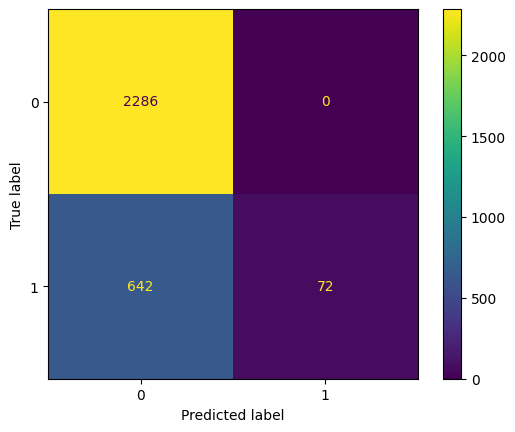

              precision    recall  f1-score   support

           0      0.781     1.000     0.877      2286
           1      1.000     0.101     0.183       714

    accuracy                          0.786      3000
   macro avg      0.890     0.550     0.530      3000
weighted avg      0.833     0.786     0.712      3000



In [ ]:
# Evaluar la capacidad predictiva del modelo
cm_bagging = confusion_matrix(y_test, Y_pred5)

plt.figure(figsize= (10,10))
ax = ConfusionMatrixDisplay(cm_bagging)
ax.plot()
plt.show()

report5 = classification_report(y_test, Y_pred5, digits = 3)
print(report5)

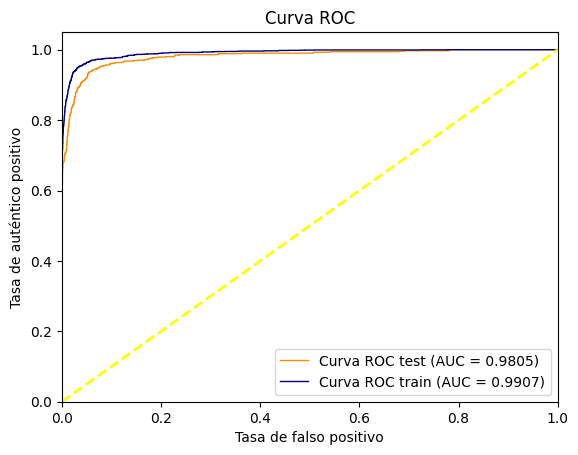

In [ ]:
#Generamos la curva ROC y calculamos el área bajo la curva
AUC_test5, AUC_train5 = plot_roc_curve(y_test, y_train, Y_pred_p5, Y_pred_train_p5, p=4)

El método de BaggingClassifier no implementa la relevancia de los parámetros, de modo que no podemos obtener este dato para este modelo.

A la luz de los resultados obtenidos, a pesar de que el área bajo la curva ROC devuelva unos resultados muy buenos, si vemos la matriz de confusión y los f-score, vemos que el resultado general es mucho más pobre que para los cuatro modelos anteriores.

Tanto el recall de 0 como la precisión de 1 es perfecta, pero si evaluamos la matriz de confusión vemos que lo que ocurre es que el predictor base ha introducido un importante sesgo, a pesar de que la varianza no haya cambiado. Ahora la mayoría de casos de '1' o 'marcha' son erroneamente catalogados como '0' o 'permanece'. Sí vamos que nunca comete errores prediciendo los empleados que se quedarán, pero falla más predicciones de las que acierta en el caso de los empleados que sí van a marcharse. Por tanto este modelo no es útil, podría estudiarse si el ajuste de hiperparámetros introducidos para el modelo de KNN es el que provoca el sesgo o es más indicado el uso de árboles de decisión en este caso.

También hay que señalar que, dado el funcionamiento del modelo KNN, que almacena toda la información y evalua los casos uno a uno cuando se pide una predicción, este modelo es mucho más lento en su uso que los cuatro anteriores.